In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# 군집 : DBSCAN - 이상치 파악

In [148]:
orig_df = pd.read_csv(
    "./data/real_world_data/customer_segments.csv"
)
df = orig_df.copy()
df.head()

,Customer_ID,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,Region
0,30001,24,9,505714,45856,0.47,0.05,16,10,4.7,Seoul
1,30002,42,2,73314,41320,0.22,0.01,10,4,4.0,Seoul
2,30003,39,10,215402,23642,0.20,0.14,11,14,3.3,Seoul
3,30004,21,4,343927,65800,0.15,0.07,9,3,4.0,Seoul
4,30005,2,19,1633920,70789,0.17,0.05,18,46,4.8,Seoul


In [149]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       8000 non-null   int64  
 1   Recency_Days      8000 non-null   int64  
 2   Frequency_90D     8000 non-null   int64  
 3   Monetary_90D      8000 non-null   int64  
 4   Avg_Basket        8000 non-null   int64  
 5   Discount_Ratio    8000 non-null   float64
 6   Return_Ratio      8000 non-null   float64
 7   Web_Visits_30D    8000 non-null   int64  
 8   App_Sessions_30D  8000 non-null   int64  
 9   Review_Score      8000 non-null   float64
 10  Region            8000 non-null   str    
dtypes: float64(3), int64(7), str(1)
memory usage: 687.6 KB


In [150]:
cols_to_drop = ["Customer_ID", "Region"]
cols_to_std = ["Recency_Days", "Frequency_90D", "Monetary_90D", "Avg_Basket", "Discount_Ratio", "Return_Ratio", "Web_Visits_30D", "App_Sessions_30D", "Review_Score"]

In [ ]:
X = df[cols_to_std]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# X_scaled를 관리하기 쉽게 데이터프레임형으로 바꿔준다.
X_scaled = pd.DataFrame(data=X_scaled, columns=X[cols_to_std].columns)

dbscan = DBSCAN(eps=1.4, min_samples=18)       # 실무 추천 값 : min_samples = 2 × dimension, 여기선 k = 18
labels = dbscan.fit_predict(X_scaled)

print("이상치 데이터의 갯수: ", np.sum(labels==-1))

이상치 데이터의 갯수:  270


가장 적절한 eps : 1.5321813973086642


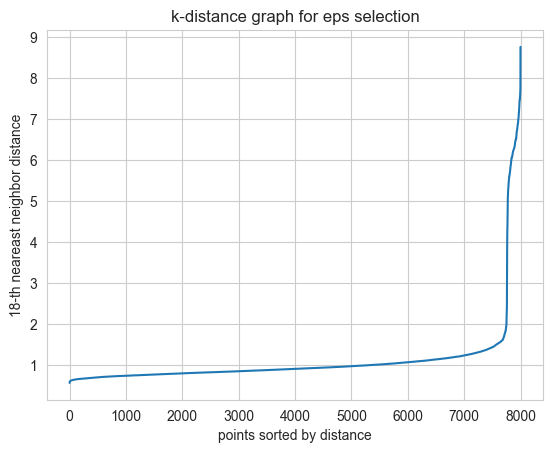

In [169]:
# DBSCAN의 eps값을 정하기 위해 k-distance graph를 그려보자.
# 그래프에서 급격히 변화하는 지점이 eps값이 될 수 있다.
# 아래의 경우는 1.4 ~ 1.5 정도에서 급격히 변화하는 것을 볼 수 있다.

k = 18

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances_sorted = np.sort(distances[:, k-1])

eps = np.percentile(distances_sorted, 95)

print(f"가장 적절한 eps : {eps}")

sns.set_style("whitegrid")
sns.lineplot(x=range(len(distances_sorted)), y=distances_sorted)
plt.xlabel("points sorted by distance")
plt.ylabel(f"{k}-th neareast neighbor distance")
plt.title("k-distance graph for eps selection")
plt.show()

In [170]:
dbscan = DBSCAN(eps=eps, min_samples=k)       # 실무 추천 값 : min_samples = 2 × dimension
labels = dbscan.fit_predict(X_scaled)

print("이상치 데이터의 갯수: ", np.sum(labels==-1))

이상치 데이터의 갯수:  252


In [171]:
# 이상치 (-1) 을 제외한 군집의 개수는 2개 ( 0, 1 )
set(labels)

{np.int64(-1), np.int64(0)}

In [172]:
X["cluster"] = labels
X.head()

,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,cluster
0,24,9,505714,45856,0.47,0.05,16,10,4.7,0
1,42,2,73314,41320,0.22,0.01,10,4,4.0,0
2,39,10,215402,23642,0.20,0.14,11,14,3.3,0
3,21,4,343927,65800,0.15,0.07,9,3,4.0,0
4,2,19,1633920,70789,0.17,0.05,18,46,4.8,0


In [173]:
outliers = X[X["cluster"] == -1]

print("이상치 데이터의 갯수: ", len(outliers))
print("이상치 데이터의 비율: ", (len(outliers) / len(X)) * 100, "%")

이상치 데이터의 갯수:  252
이상치 데이터의 비율:  3.15 %


## 시각화

### PCA

In [193]:
X_clean = X[X["cluster"] != -1]

X_clean_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=X_clean.columns)
X_clean_scaled.head()

,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,cluster
0,-0.116615,0.281118,0.460322,0.183100,0.356798,-0.639382,0.279157,-0.413523,1.001161,0.0
1,0.626967,-1.169429,-0.900133,-0.280115,-0.686210,-0.930987,-0.579708,-0.947890,-0.447082,0.0
2,0.503036,0.488338,-0.453083,-2.085387,-0.769651,0.016729,-0.436564,-0.057278,-1.895324,0.0
3,-0.240546,-0.754987,-0.048706,2.219774,-0.978252,-0.493580,-0.722852,-1.036951,-0.447082,0.0
4,-1.025438,2.353327,4.009985,2.729249,-0.894812,-0.639382,0.565446,2.792679,1.208052,0.0


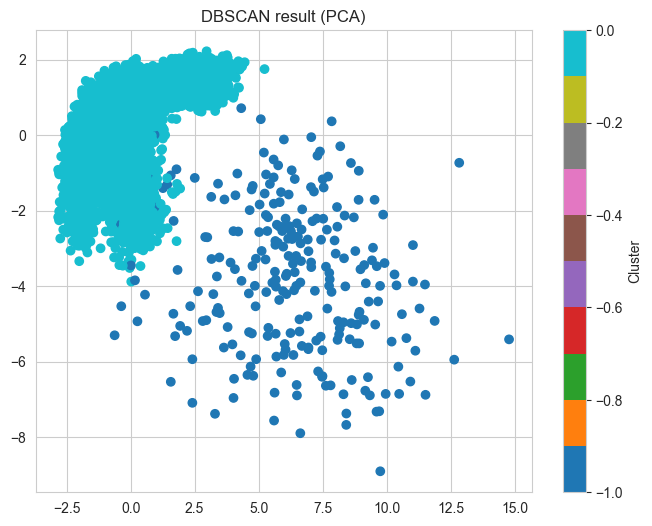

In [194]:
# 이상치 시각화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=X["cluster"],
    cmap="tab10"
)
plt.colorbar(label="Cluster")
plt.title("DBSCAN result (PCA)")
plt.show()


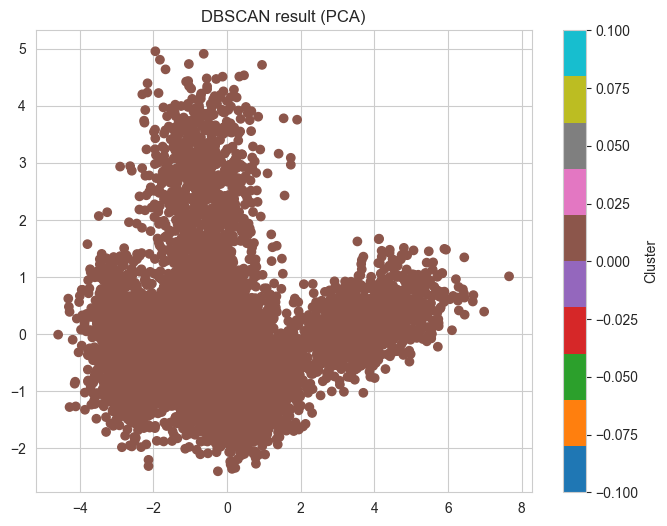

In [195]:
# 이상치 제거 시각화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean_scaled[cols_to_std])

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=X[X["cluster"] != -1]["cluster"],
    cmap="tab10"
)
plt.colorbar(label="Cluster")
plt.title("DBSCAN result (PCA)")
plt.show()


### UMAP

In [196]:
'''
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_clean_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=X_clean["cluster"],
    cmap="tab10"
)
plt.colorbar()
plt.title("DBSCAN result (UMAP)")
plt.show()
'''

'\nimport umap\n\nreducer = umap.UMAP(\n    n_components=2,\n    n_neighbors=15,\n    min_dist=0.1,\n    random_state=42\n)\n\nX_umap = reducer.fit_transform(X_clean_scaled)\n\nplt.figure(figsize=(8,6))\nplt.scatter(\n    X_umap[:,0],\n    X_umap[:,1],\n    c=X_clean["cluster"],\n    cmap="tab10"\n)\nplt.colorbar()\nplt.title("DBSCAN result (UMAP)")\nplt.show()\n'

### t-SNE (Visualization 최강이지만 느림)

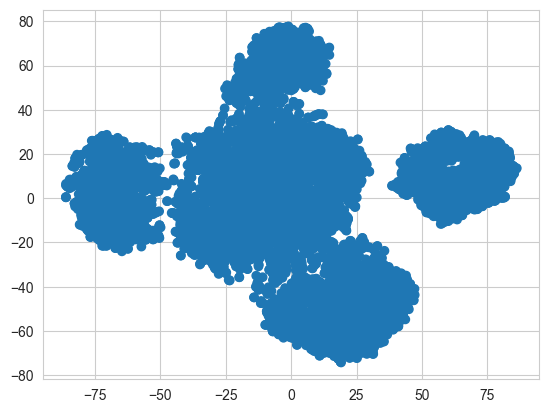

In [197]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_clean_scaled[cols_to_std])

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=X_clean["cluster"],
    cmap="tab10"
)
plt.show()

## K-Means Clustering

In [227]:
kmeans_model = KMeans(n_clusters=4, random_state=3333)
kmeans_model.fit(X_clean)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",3333
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [228]:
kmeans_model.labels_

array([2, 1, 1, ..., 1, 1, 1], shape=(7748,), dtype=int32)

In [229]:
X_clean["cluster"] = kmeans_model.labels_
X_clean.head()

,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,cluster
0,24,9,505714,45856,0.47,0.05,16,10,4.7,2
1,42,2,73314,41320,0.22,0.01,10,4,4.0,1
2,39,10,215402,23642,0.20,0.14,11,14,3.3,1
3,21,4,343927,65800,0.15,0.07,9,3,4.0,2
4,2,19,1633920,70789,0.17,0.05,18,46,4.8,3


### K-Means 시각화 (t-SNE)

In [230]:
optimal_locations = kmeans_model.cluster_centers_
optimal_locations

array([[1.04696449e+01, 1.38774341e+01, 7.79684397e+05, 5.27810561e+04,
        2.54169530e-01, 1.01466208e-01, 2.02703322e+01, 2.92050401e+01,
        4.55681558e+00, 1.76861397e+00],
       [3.78862260e+01, 4.29654991e+00, 1.42342420e+05, 3.96774662e+04,
        3.76455096e-01, 1.42354490e-01, 1.11182513e+01, 9.26283908e+00,
        4.08438241e+00, 1.22939162e+00],
       [1.94648892e+01, 8.61547127e+00, 3.83651044e+05, 4.52429170e+04,
        4.79136312e-01, 1.53882839e-01, 1.49515584e+01, 1.43372137e+01,
        4.21592189e+00, 2.61284266e+00],
       [7.21686747e+00, 1.89132530e+01, 1.30575547e+06, 5.82773759e+04,
        1.24602410e-01, 6.75903614e-02, 2.20000000e+01, 3.52000000e+01,
        4.70554217e+00, 2.00240964e+00]])

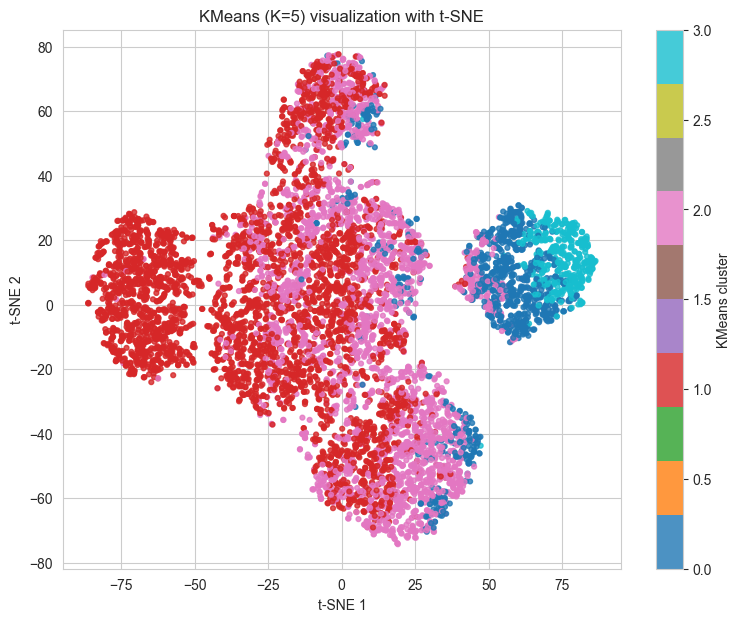

In [231]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_2d = tsne.fit_transform(X_clean_scaled[cols_to_std])

plt.figure(figsize=(9, 7))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=X_clean["cluster"], s=12, cmap="tab10", alpha=0.8)
plt.colorbar(label="KMeans cluster")
plt.title("KMeans (K=5) visualization with t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [232]:
X_clean = X_clean.copy()

cluster_profile = X_clean.groupby("cluster")[cols_to_std].mean()
cluster_profile.round(2)

,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score
cluster,,,,,,,,,
0,10.47,13.88,779684.40,52781.06,0.25,0.10,20.27,29.21,4.56
1,37.85,4.30,142564.18,39684.27,0.38,0.14,11.12,9.26,4.08
2,19.46,8.62,383969.41,45247.84,0.48,0.15,14.95,14.35,4.22
3,7.22,18.91,1305755.47,58277.38,0.12,0.07,22.00,35.20,4.71


In [233]:
# z-score로 계산하고 고객 유형을 판단하기:
## 0을 기준으로 높고 낮음을 판단 가능.
## 클러스터별 고객 유형 정의 가능
cluster_profile_z = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std()

cluster_profile_z.round(2)

,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score
cluster,,,,,,,,,
0,-0.60,0.39,0.25,0.46,-0.36,-0.38,0.64,0.59,0.57
1,1.39,-1.12,-1.00,-1.14,0.44,0.67,-1.20,-1.04,-1.06
2,0.05,-0.44,-0.53,-0.46,1.11,0.94,-0.43,-0.63,-0.60
3,-0.84,1.18,1.28,1.13,-1.20,-1.23,0.99,1.08,1.09


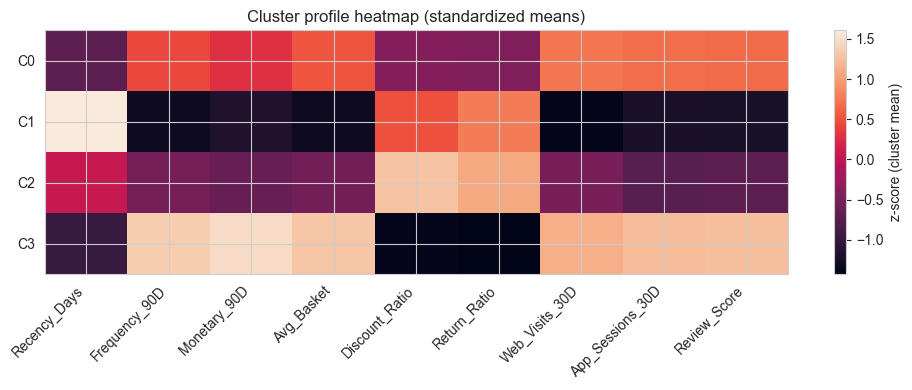

In [236]:
prof = X_clean.groupby("cluster")[cols_to_std].mean()
prof_z = (prof - prof.mean()) / prof.std(ddof=0)

plt.figure(figsize=(10, 4))
plt.imshow(prof_z.values, aspect="auto")
plt.yticks(range(4), [f"C{i}" for i in range(4)])
plt.xticks(range(len(cols_to_std)), cols_to_std, rotation=45, ha="right")
plt.colorbar(label="z-score (cluster mean)")
plt.title("Cluster profile heatmap (standardized means)")
plt.tight_layout()
plt.show()

In [237]:
# k = 4일 경우의 silhouette_score.
kmeans_labels = kmeans_model.fit_predict(X_clean_scaled)

score = silhouette_score(X_clean_scaled, kmeans_labels)

print(score)

0.288602204456521


In [226]:
## 우리가 다루는 도메인에 따라 k의 갯수가 달라질 수 있다. 예를 들어 고객 segmentation같은 경우
## VIP, Loyal, Discount hunters, Churn risk, Casual 이런식으로 4~6개가 industry standard이다.

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=3333)
    labels = kmeans.fit_predict(X_clean_scaled)
    score = silhouette_score(X_clean_scaled, labels)
    print(f"K={k}, silhouette={score:.4f}")

K=2, silhouette=0.3816
K=3, silhouette=0.2558
K=4, silhouette=0.2886
K=5, silhouette=0.2459
K=6, silhouette=0.2488
K=7, silhouette=0.2390
K=8, silhouette=0.1996
K=9, silhouette=0.1866
K=10, silhouette=0.1638


In [ ]:
X_clean.groupby("cluster").mean().round(2)

,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score
cluster,,,,,,,,,
0,10.47,13.88,779684.40,52781.06,0.25,0.10,20.27,29.21,4.56
1,37.85,4.30,142564.18,39684.27,0.38,0.14,11.12,9.26,4.08
2,19.46,8.62,383969.41,45247.84,0.48,0.15,14.95,14.35,4.22
3,7.22,18.91,1305755.47,58277.38,0.12,0.07,22.00,35.20,4.71


In [ ]:
## cluster 3 : VIP
## cluster 0 : Loyal High-Value Customers -  VIP 다음으로 충성도가 높은 고객층
## cluster 2 : Discount Sensitive -  할인 의존 매우 높음, 구매력 중간, 반품률 높음
## cluster 1 : Churn Risk -  오래 안옴, engagement 낮음

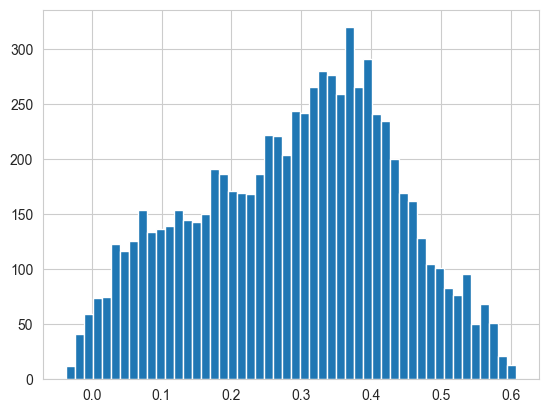

In [ ]:
## Negative 숫자가 없을 수록 좋은 validation
from sklearn.metrics import silhouette_samples

vals = silhouette_samples(X_clean_scaled, kmeans_labels)

plt.hist(vals, bins=50)
plt.show()

In [241]:
cluster_name_map = {
    3: "VIP Customers",
    0: "Loyal Customers",
    2: "Discount Hunters",
    1: "Churn Risk Customers"
}

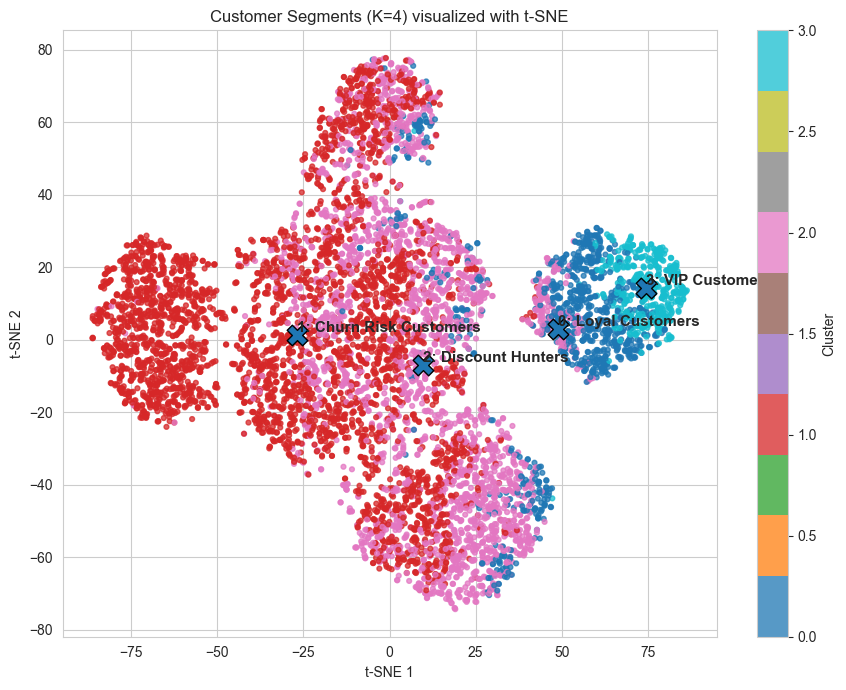

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_2d = tsne.fit_transform(X_clean_scaled)

plt.figure(figsize=(9, 7))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=X_clean["cluster"], s=12, alpha=0.75, cmap="tab10")
plt.colorbar(sc, label="Cluster")

# cluster 중심점(=t-SNE 공간에서의 평균 위치)
K = X_clean["cluster"].nunique()
centroids_2d = np.vstack([X_2d[X_clean["cluster"].values == c].mean(axis=0) for c in sorted(X_clean["cluster"].unique())])

plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=220, marker="X", edgecolor="black")

# 중심 라벨
for idx, c in enumerate(sorted(X_clean["cluster"].unique())):
    name = cluster_name_map.get(c, f"Cluster {c}")
    x, y = centroids_2d[idx]
    plt.text(x, y, f"{c}: {name}", fontsize=11, weight="bold", va="bottom")

plt.title("Customer Segments (K=4) visualized with t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


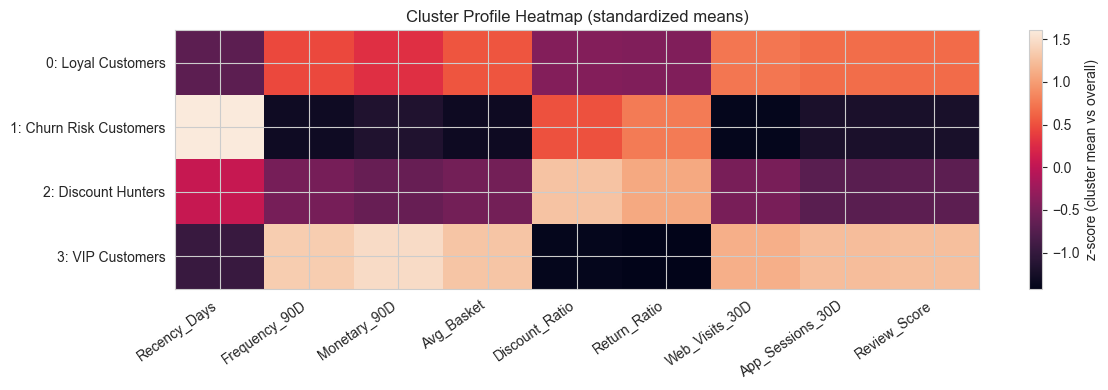

In [243]:
cluster_profile = X_clean.groupby("cluster")[cols_to_std].mean()

# z-score (열 기준)
prof_z = (cluster_profile - cluster_profile.mean(axis=0)) / cluster_profile.std(axis=0, ddof=0)

plt.figure(figsize=(12, 4))
im = plt.imshow(prof_z.values, aspect="auto")
plt.colorbar(im, label="z-score (cluster mean vs overall)")

plt.yticks(range(len(prof_z.index)), [f"{c}: {cluster_name_map.get(c, c)}" for c in prof_z.index])
plt.xticks(range(len(cols_to_std)), cols_to_std, rotation=35, ha="right")

plt.title("Cluster Profile Heatmap (standardized means)")
plt.tight_layout()
plt.show()